Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3462 - val_loss: 0.2028
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1907 - val_loss: 0.1699
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1672 - val_loss: 0.1571
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1563 - val_loss: 0.1511
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1511 - val_loss: 0.1474
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step


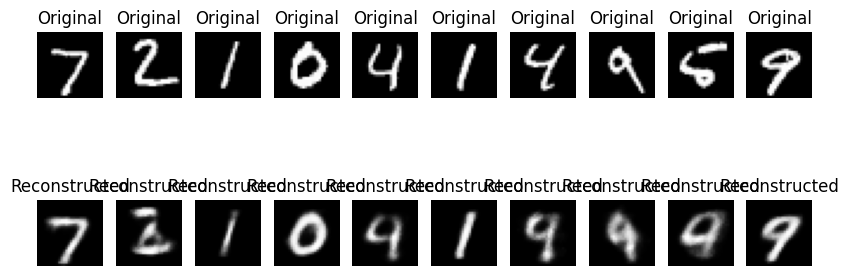

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train,_),(x_test,_)=tf.keras.datasets.mnist.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(len(x_train),784)
x_test=x_test.reshape(len(x_test),784)

noise=0.3
x_train_noisy=tf.clip_by_value(x_train+noise*tf.random.normal(x_train.shape),0,1)
x_test_noisy=tf.clip_by_value(x_test+noise*tf.random.normal(x_test.shape),0,1)

input_img=layers.Input(shape=(784,))
encoded=layers.Dense(128,activation='relu')(input_img)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(32,activation='relu')(encoded)
encoded=layers.Dense(16,activation='relu')(encoded)


decoded=layers.Dense(64,activation='relu')(encoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)

autoencoder=models.Model(input_img,decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

decoded_imgs=autoencoder.predict(x_test_noisy)

n=10
plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("Original")
    plt.axis("off")

    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3380 - val_loss: 0.1680
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1604 - val_loss: 0.1389
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1367 - val_loss: 0.1280
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1266 - val_loss: 0.1199
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1194 - val_loss: 0.1147
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step


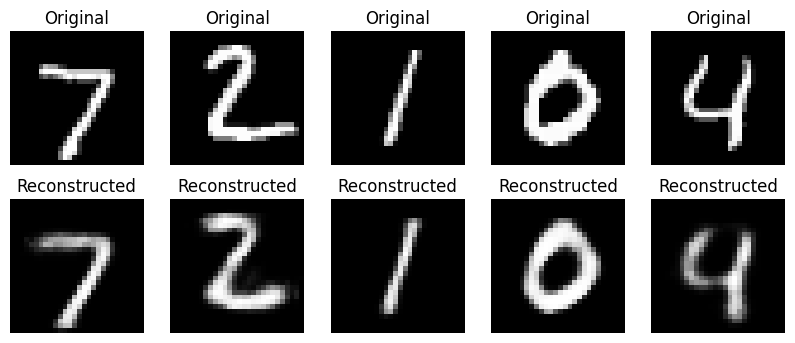

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train,_),(x_test,_)=tf.keras.datasets.mnist.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
input_img=layers.Input(shape=(28,28))

flat=layers.Flatten()(input_img)

encoded=layers.Dense(128,activation='relu')(flat)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(32,activation='relu')(encoded)

decoded=layers.Dense(64,activation='relu')(encoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)
decoded=layers.Reshape((28,28))(decoded)

autoencoder=models.Model(input_img,decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test,x_test)
)

decoded_imgs=autoencoder.predict(x_test)

n=5
plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("Original")
    plt.axis("off")

    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()